In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.manual_seed(0)
np.random.seed(0)

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from neural_decoder.neural_decoder_trainer import getDatasetLoaders

In [2]:
import pickle

with open('../data/ptDecoder_ctc', "rb") as handle:
    loadedData = pickle.load(handle)

In [3]:
from neural_decoder.dataset import SpeechDataset
train_ds = SpeechDataset(loadedData["train"], transform=None)

In [4]:
num_trials = 8800
num_electrodes = 128
num_feats = 2

# Creates single concatenated list per electrode per feature
buffers = [[[] for _ in range(num_electrodes)] for _ in range(num_feats)]

for i in range(num_trials):
    X = train_ds[i][0]
    X = X.squeeze().numpy()
    L = X.shape[0]

    trial_fc = X.reshape(L, num_feats, num_electrodes)

    for f in range(num_feats):
        data_f = trial_fc[:, f, :]
        for ch in range(num_electrodes):
            buffers[f][ch].append(data_f[:, ch])

# final vectors: feature × channel × samples
channel_vectors = [
    np.array([np.concatenate(buffers[f][ch]) for ch in range(num_electrodes)])
    for f in range(num_feats)
]

threshold_crossings = channel_vectors[0]
spike_band_power = channel_vectors[1]

In [5]:
tc_centered = threshold_crossings - threshold_crossings.mean(axis=1).reshape(-1, 1)
sbp_centered = spike_band_power - spike_band_power.mean(axis=1).reshape(-1, 1)

In [6]:
cov_tc = tc_centered @ tc_centered.T / tc_centered.shape[1]
cov_sbp = sbp_centered @ sbp_centered.T / sbp_centered.shape[1]

In [7]:
evals_tc, pcs_tc = np.linalg.eig(cov_tc)
evals_sbp, pcs_sbp = np.linalg.eig(cov_sbp)

In [8]:
pc_var_tc = np.cumsum(evals_tc) / evals_tc.sum()
np.where(pc_var_tc > 0.9)[0].min()

114

In [9]:
pc_var_sbp = np.cumsum(evals_sbp) / evals_sbp.sum()
np.where(pc_var_sbp > 0.9)[0].min()

114

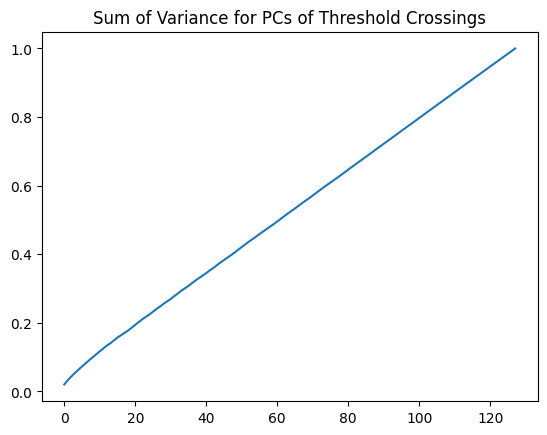

In [10]:
plt.plot(np.cumsum(evals_tc) / evals_tc.sum())
plt.title('Sum of Variance for PCs of Threshold Crossings')
plt.show()

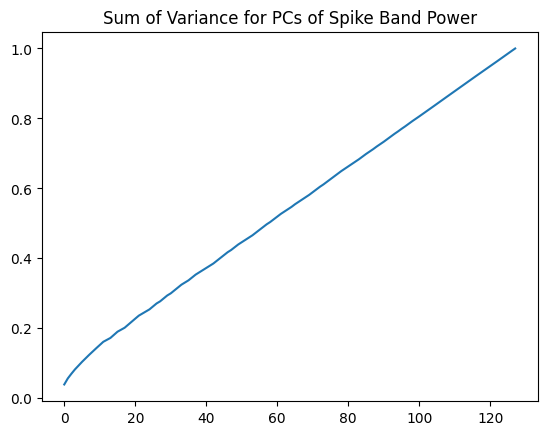

In [11]:
plt.plot(np.cumsum(evals_sbp) / evals_sbp.sum())
plt.title('Sum of Variance for PCs of Spike Band Power')
plt.show()

In [42]:
np.save("../data/threshold_crossing_principal_components.npy", pcs_tc)
np.save("../data/threshold_crossings_mean.npy", threshold_crossings.mean(axis=1).reshape(-1, 1))

np.save("../data/spike_band_power_principal_components.npy", pcs_sbp)
np.save("../data/spike_band_power_mean.npy", spike_band_power.mean(axis=1).reshape(-1, 1))

In [13]:
pcs_tc.shape

(128, 128)

In [15]:
threshold_crossings.mean(axis=1).reshape(-1, 1).shape

(128, 1)

In [26]:
tc_mean = threshold_crossings.mean(axis=1).reshape(-1, 1)
sbp_mean = spike_band_power.mean(axis=1).reshape(-1, 1)

In [ ]:
sample_point = loadedData['train'][0]["sentenceDat"][0]
sample_tcs = sample_point.T[:128]
sample_sbp = sample_point.T[128:]

num_pcs = 100

tc_new = (pcs_tc[:, :num_pcs].T @ (sample_tcs - tc_mean)).T
sbp_new = (pcs_sbp[:, :num_pcs].T @ (sample_sbp - sbp_mean)).T

sample_new = np.concatenate([tc_new, sbp_new], axis=1)

In [ ]:
# compute correlations feature-wise
corr_matrices = [
    np.corrcoef(np.vstack(channel_vectors[f]))
    for f in range(num_feats)
]

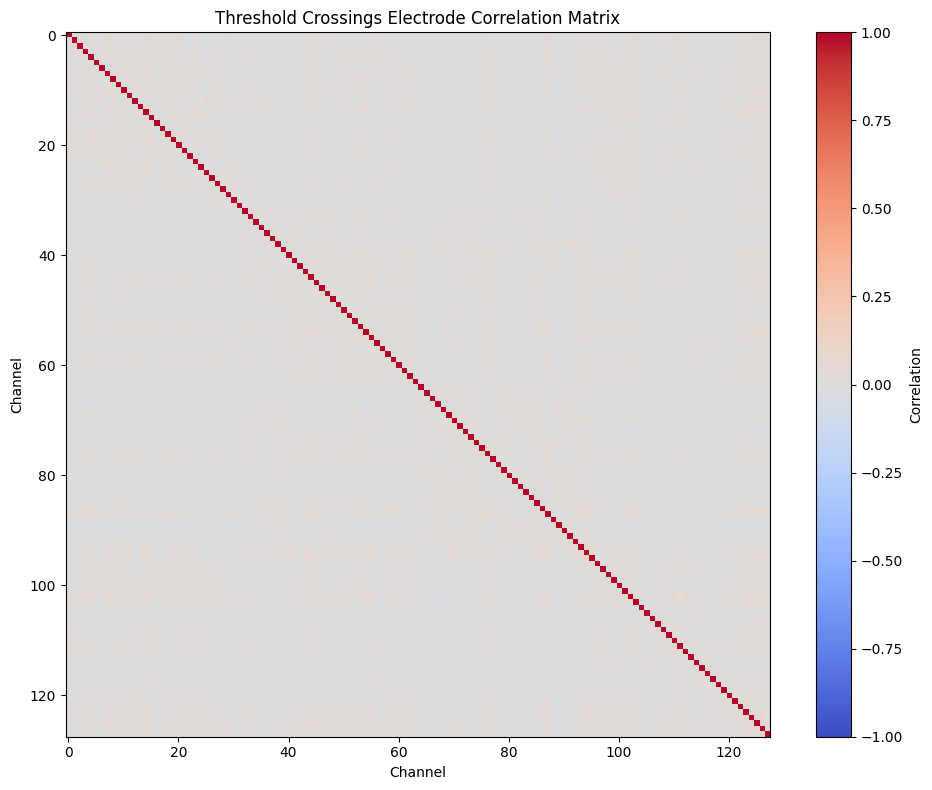

In [6]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrices[0], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Threshold Crossings Electrode Correlation Matrix")
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

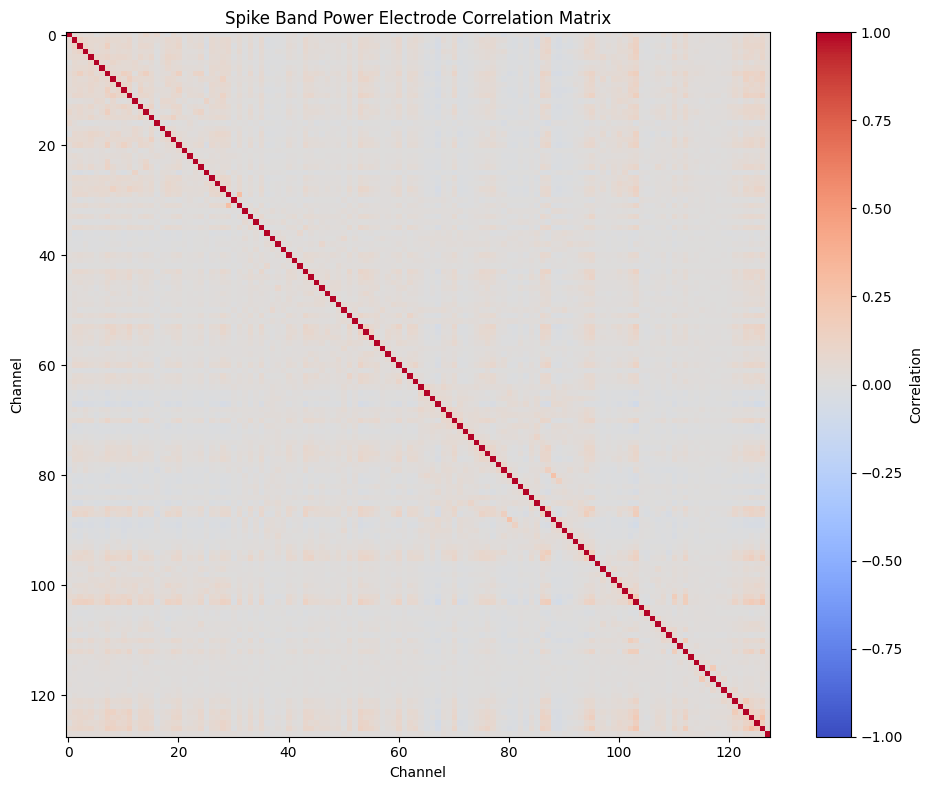

In [7]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrices[1], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Spike Band Power Electrode Correlation Matrix")
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

In [8]:
tc = corr_matrices[0].copy()
np.fill_diagonal(tc, 0)

sbp = corr_matrices[1].copy()
np.fill_diagonal(sbp, 0)

product = (tc + sbp) / 2

In [9]:
sorted_indices_flat = np.argsort(product.ravel())[::-1]

rows, cols = np.unravel_index(sorted_indices_flat, product.shape)
sorted_indices = list(zip(rows, cols))
sorted_indices = sorted_indices[::2] # remove duplicates (i,j) and (j,i)

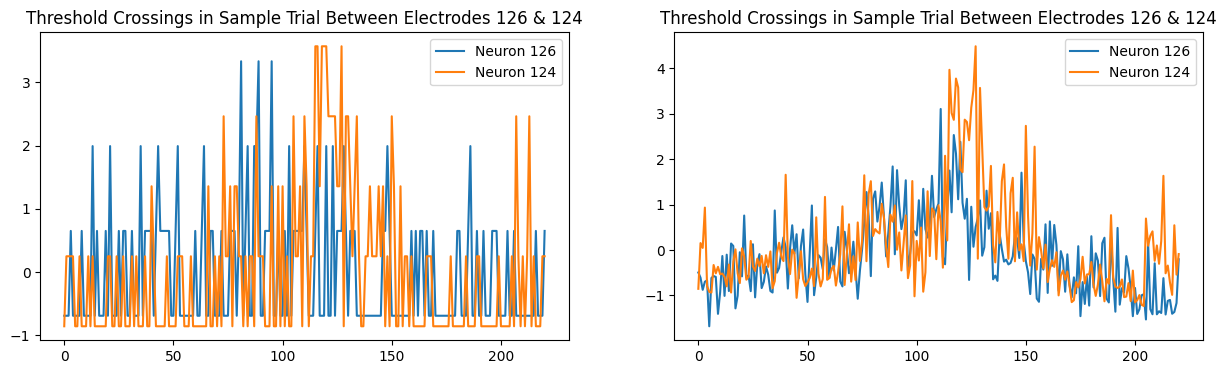

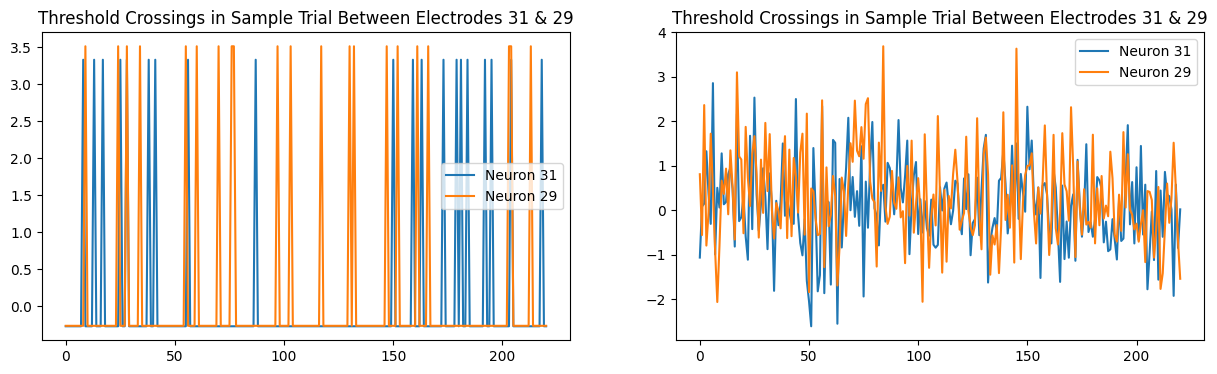

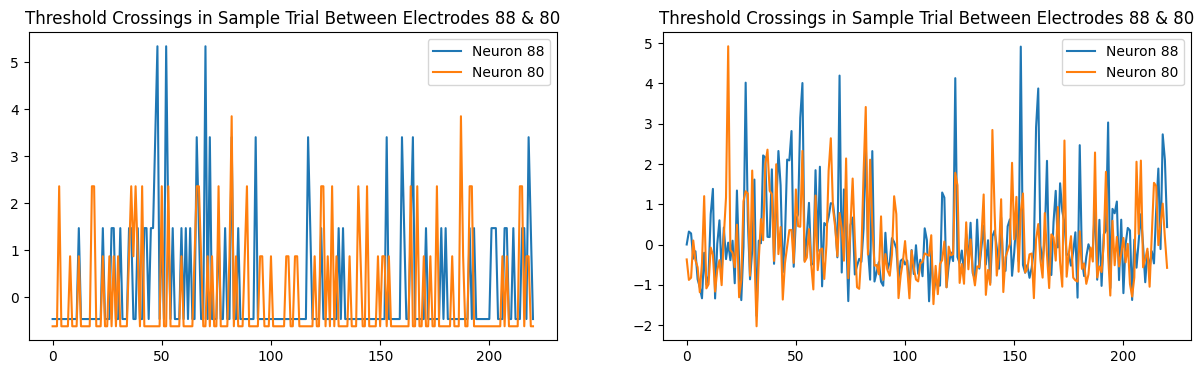

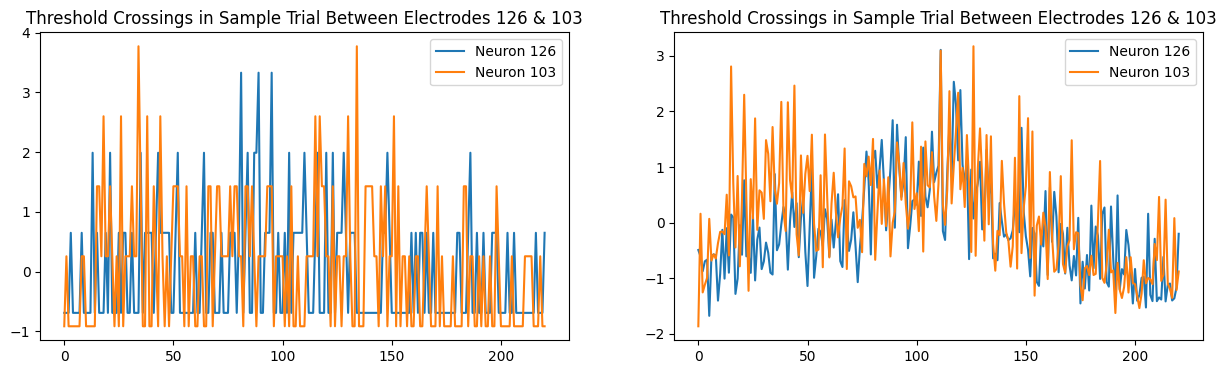

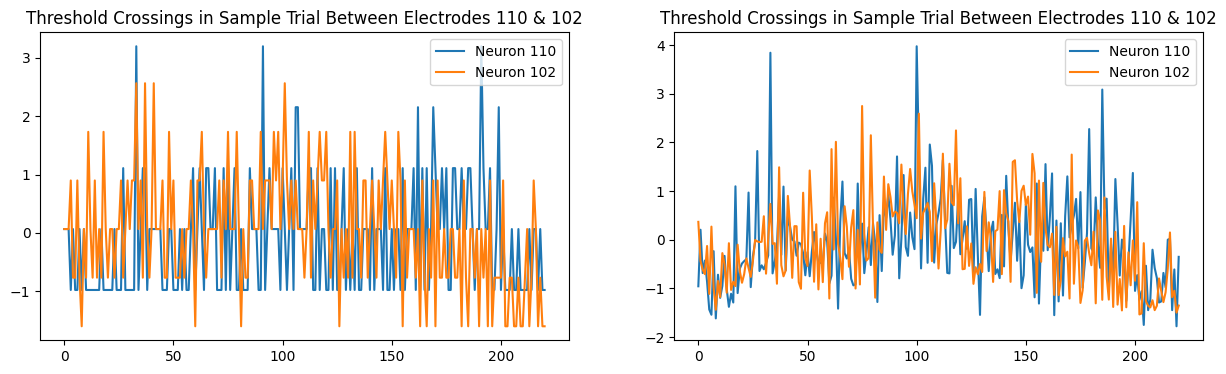

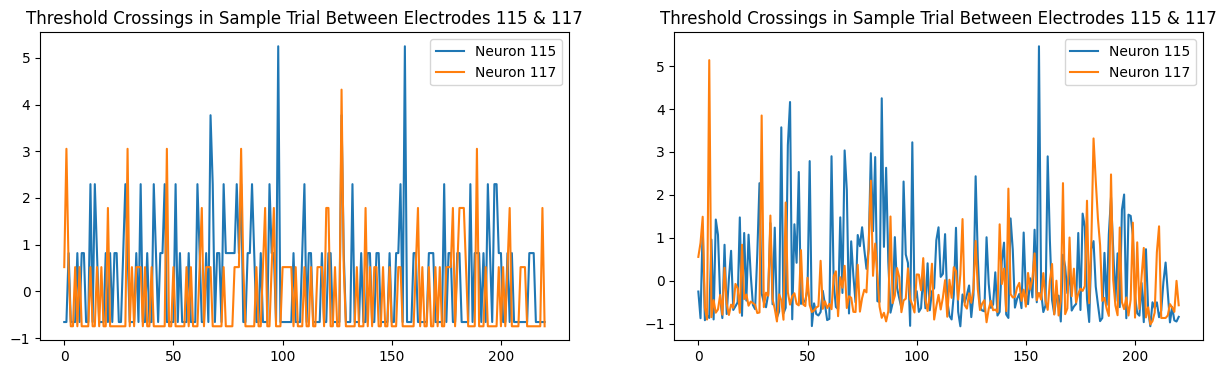

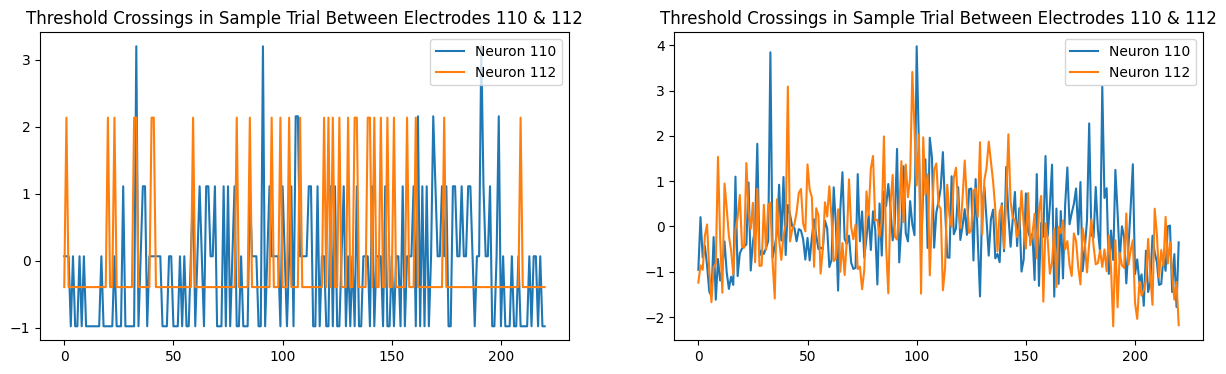

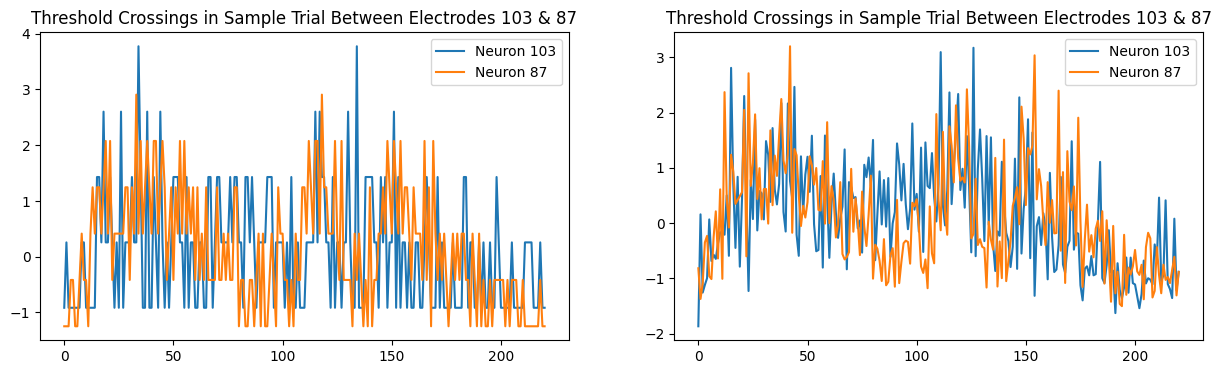

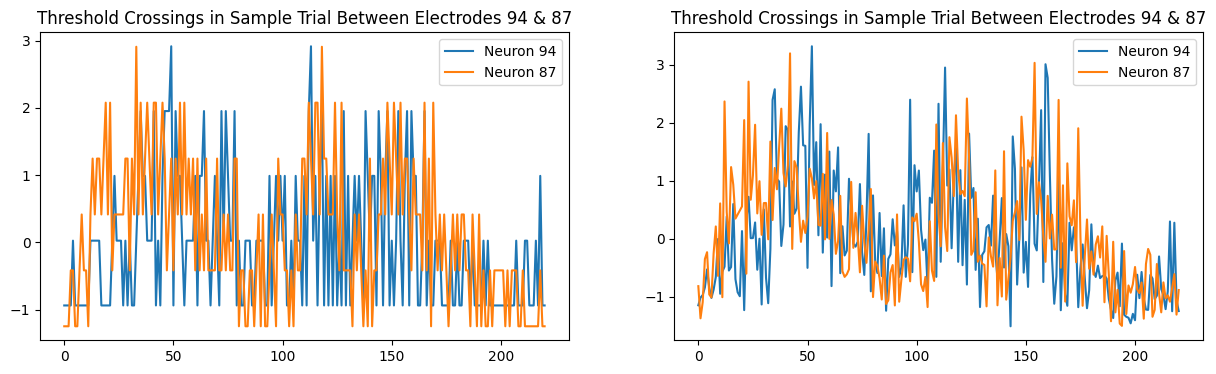

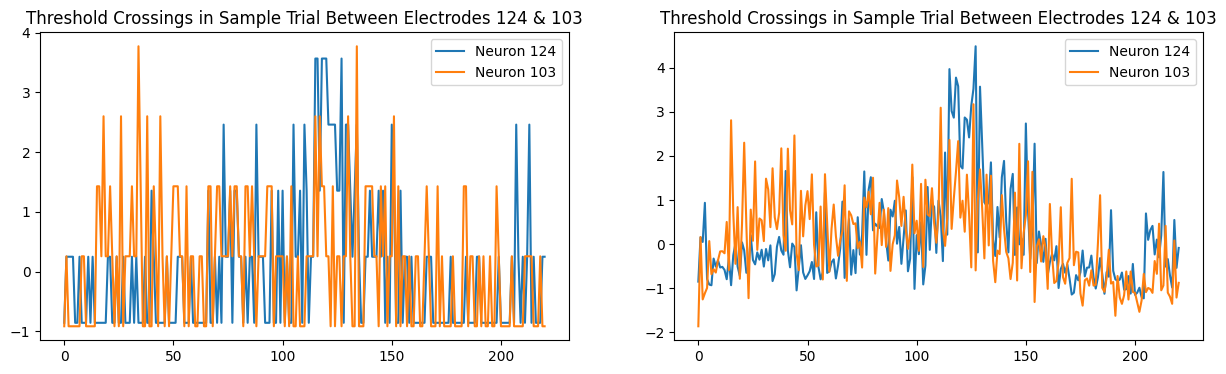

In [10]:
for electrode1, electrode2 in sorted_indices[:10]:
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(X[:, electrode1].shape[0]), X[:, electrode1], label=f"Neuron {electrode1}")
    plt.plot(np.arange(X[:, electrode2].shape[0]), X[:, electrode2], label=f"Neuron {electrode2}")
    plt.title(f"Threshold Crossings in Sample Trial Between Electrodes {electrode1} & {electrode2}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(np.arange(X[:, electrode1+128].shape[0]), X[:, electrode1+128], label=f"Neuron {electrode1}")
    plt.plot(np.arange(X[:, electrode2+128].shape[0]), X[:, electrode2+128], label=f"Neuron {electrode2}")
    plt.title(f"Threshold Crossings in Sample Trial Between Electrodes {electrode1} & {electrode2}")
    plt.legend()
    plt.show()

As we can see, many of these neurons are highly correlated with each other. Thus, it seems plausible that we can achieve similar model performance by dropping some of the highly correlated neurons in our data. So if we want to drop k neurons, we can find the k neurons with the highest correlation and then drop one of the two neurons in each of those pairs.

In [11]:
sorted_indices[:20]

[(126, 124),
 (31, 29),
 (88, 80),
 (126, 103),
 (110, 102),
 (115, 117),
 (110, 112),
 (103, 87),
 (94, 87),
 (124, 103),
 (103, 102),
 (102, 112),
 (123, 121),
 (112, 126),
 (126, 125),
 (126, 95),
 (94, 95),
 (7, 14),
 (95, 86),
 (126, 123)]

In [12]:
drop = set()
keep = set()

while (len(sorted_indices) > 0) & (len(drop) < 10):
    electrode1, electrode2 = sorted_indices.pop(0)
    if (
        (electrode1 not in drop and electrode2 not in drop) and
        (electrode1 not in keep and electrode2 not in keep)
    ):
         if np.random.rand() < 0.5:
            drop.add(electrode1)
            keep.add(electrode2)
         else:
            drop.add(electrode2)
            keep.add(electrode1)

In [13]:
drop

{14, 19, 29, 80, 87, 95, 102, 115, 123, 124}

In [14]:
dropped_features = list(drop)

for feature in dropped_features:
    drop.add(feature + 128)

In [15]:
new_train_ds = SpeechDataset(loadedData["train"], transform=None, electrodes_to_drop=np.array(list(drop)))
new_test_ds = SpeechDataset(loadedData["test"], electrodes_to_drop=np.array(list(drop)))

In [16]:
new_train_ds[0][0].shape

torch.Size([478, 236])